# Analysis: PCA trajectories, dPCA, spatial separation

Load stage-2 checkpoint, collect trials, analyse hidden-state geometry.

In [ ]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from src import BioLeakyRNN, CuedTargetWithDistractorsV3
from src.analysis import (
    collect_trials, filter_trials, select_trials,
    fit_pca_on_trials, get_aligned_pca_segments,
    compute_median_and_band, compute_mean_and_sem,
    dpca_marginals, collect_aligned_hidden_by_label, make_condition_mean_tensor,
    plot_spatial_separation_pca, print_centroid_distances, compare_spatial_separation,
)
from src.plotting import (
    plot_pca_trajectories, plot_pca_trajectories_by_outcome,
    plot_pc_timecourses, plot_two_group_pc_timecourses,
    plot_two_group_median_trajectories,
    plot_trialtype_panel, plot_dpca_components, plot_dpca_components_with_band,
    plot_dpca_plane,
)

device = 'cpu'
print('device:', device)

## Load model

In [20]:
def make_model():
    return BioLeakyRNN(
        input_size=7, hidden_size=128, output_size=2,
        dt=20.0, tau=100.0, activation='softplus', sigma_rec=0.05,
        use_ei=True, exc_ratio=0.7, use_dale=True, mask_seed=42,
    )

def make_env_stage2():
    return CuedTargetWithDistractorsV3(dt=20, cue_strength=1.0,
                                       p_distractor_trial=0.6, distractor_strength=1.0)

model = make_model().to(device)
model.load_state_dict(torch.load('../checkpoints/stage2.pt', weights_only=True)['state_dict'])
model.eval()
print('Loaded stage2 checkpoint.')

Loaded stage2 checkpoint.


## Collect trials

In [37]:
trials = collect_trials(model, make_env_stage2, n_trials=5000, device=device)
print(f'Collected {len(trials)} trials')
print(Counter(tr['train_outcome'] for tr in trials))

Collected 5000 trials
Counter({'correct': 4598, 'false_alarm': 379, 'abort': 12, 'miss': 11})


## PCA on hidden states

In [38]:
pca, trial_proj, explained = fit_pca_on_trials(trials, n_components=3)
print('Explained variance:', explained)

Explained variance: [0.48867634 0.22459905 0.11453959]


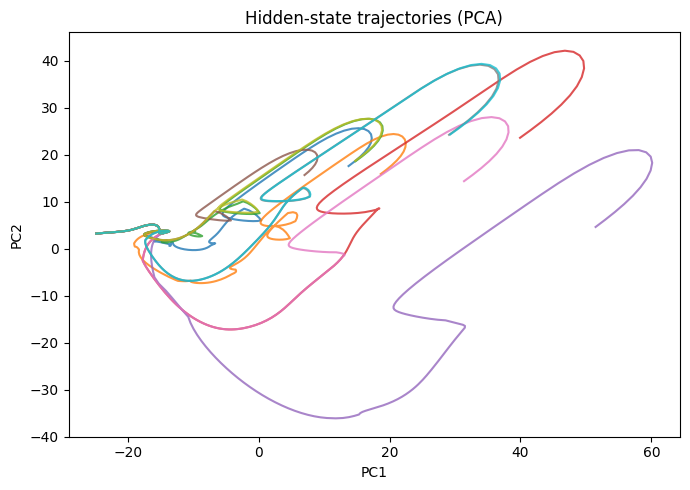

In [39]:
plot_pca_trajectories(trials, trial_proj, max_trials=10)

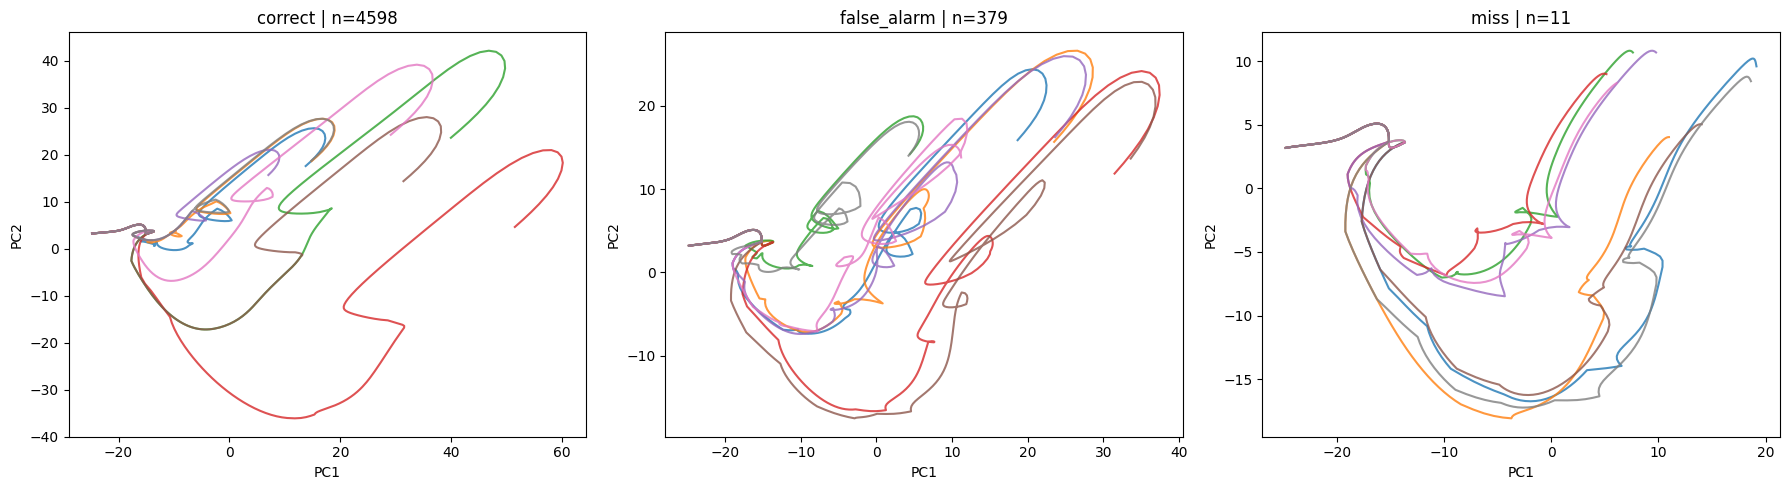

In [40]:
plot_pca_trajectories_by_outcome(trials, trial_proj,
                                  outcomes=("correct", "false_alarm", "miss"),
                                  max_per_group=8)

## Event-aligned time courses

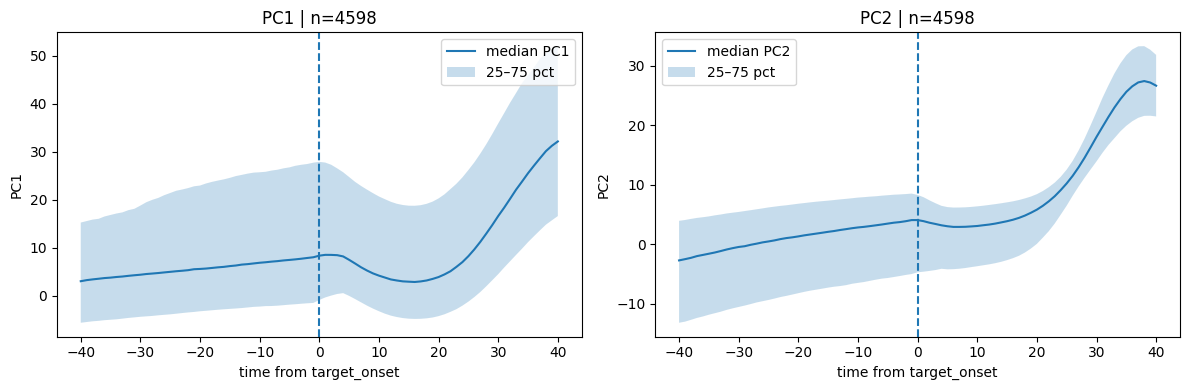

In [41]:
plot_pc_timecourses(
    trials, trial_proj,
    align_key='target_onset', window_before=40, window_after=40,
    stat_mode='median', q_low=25, q_high=75,
    train_outcome='correct',
)

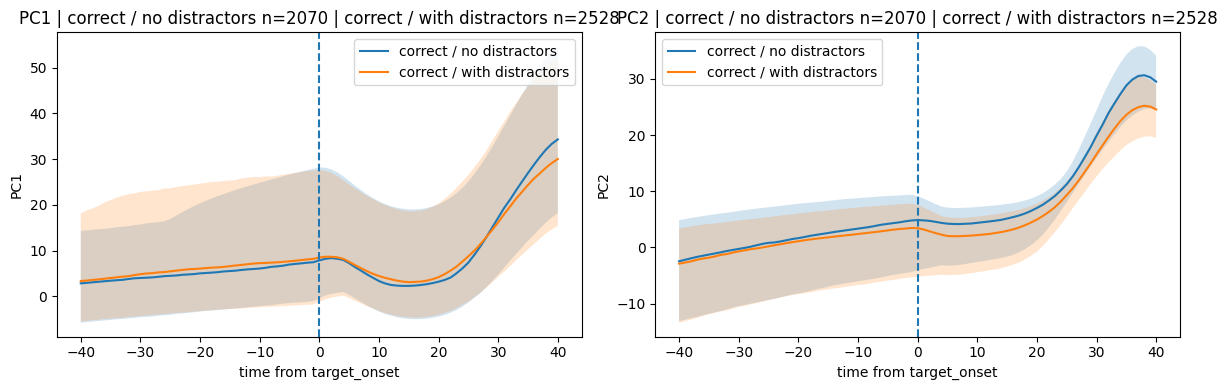

In [42]:
plot_two_group_pc_timecourses(
    trials, trial_proj,
    align_key='target_onset', window_before=40, window_after=40,
    group1_kwargs={'train_outcome': 'correct', 'has_distractors': False},
    group2_kwargs={'train_outcome': 'correct', 'has_distractors': True},
    group1_label='correct / no distractors',
    group2_label='correct / with distractors',
    stat_mode='median', q_low=25, q_high=75,
)

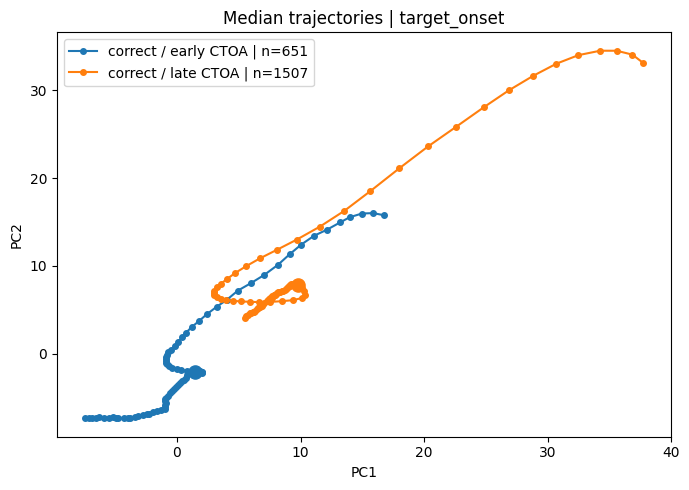

In [43]:
plot_two_group_median_trajectories(
    trials, trial_proj,
    align_key='target_onset', window_before=40, window_after=40,
    group1_kwargs={'train_outcome': 'correct', 'ctoa_bin_max': 2},
    group2_kwargs={'train_outcome': 'correct', 'ctoa_bin_min': 7},
    group1_label='correct / early CTOA',
    group2_label='correct / late CTOA',
)

## Panel: outcomes × CTOA × spatial location

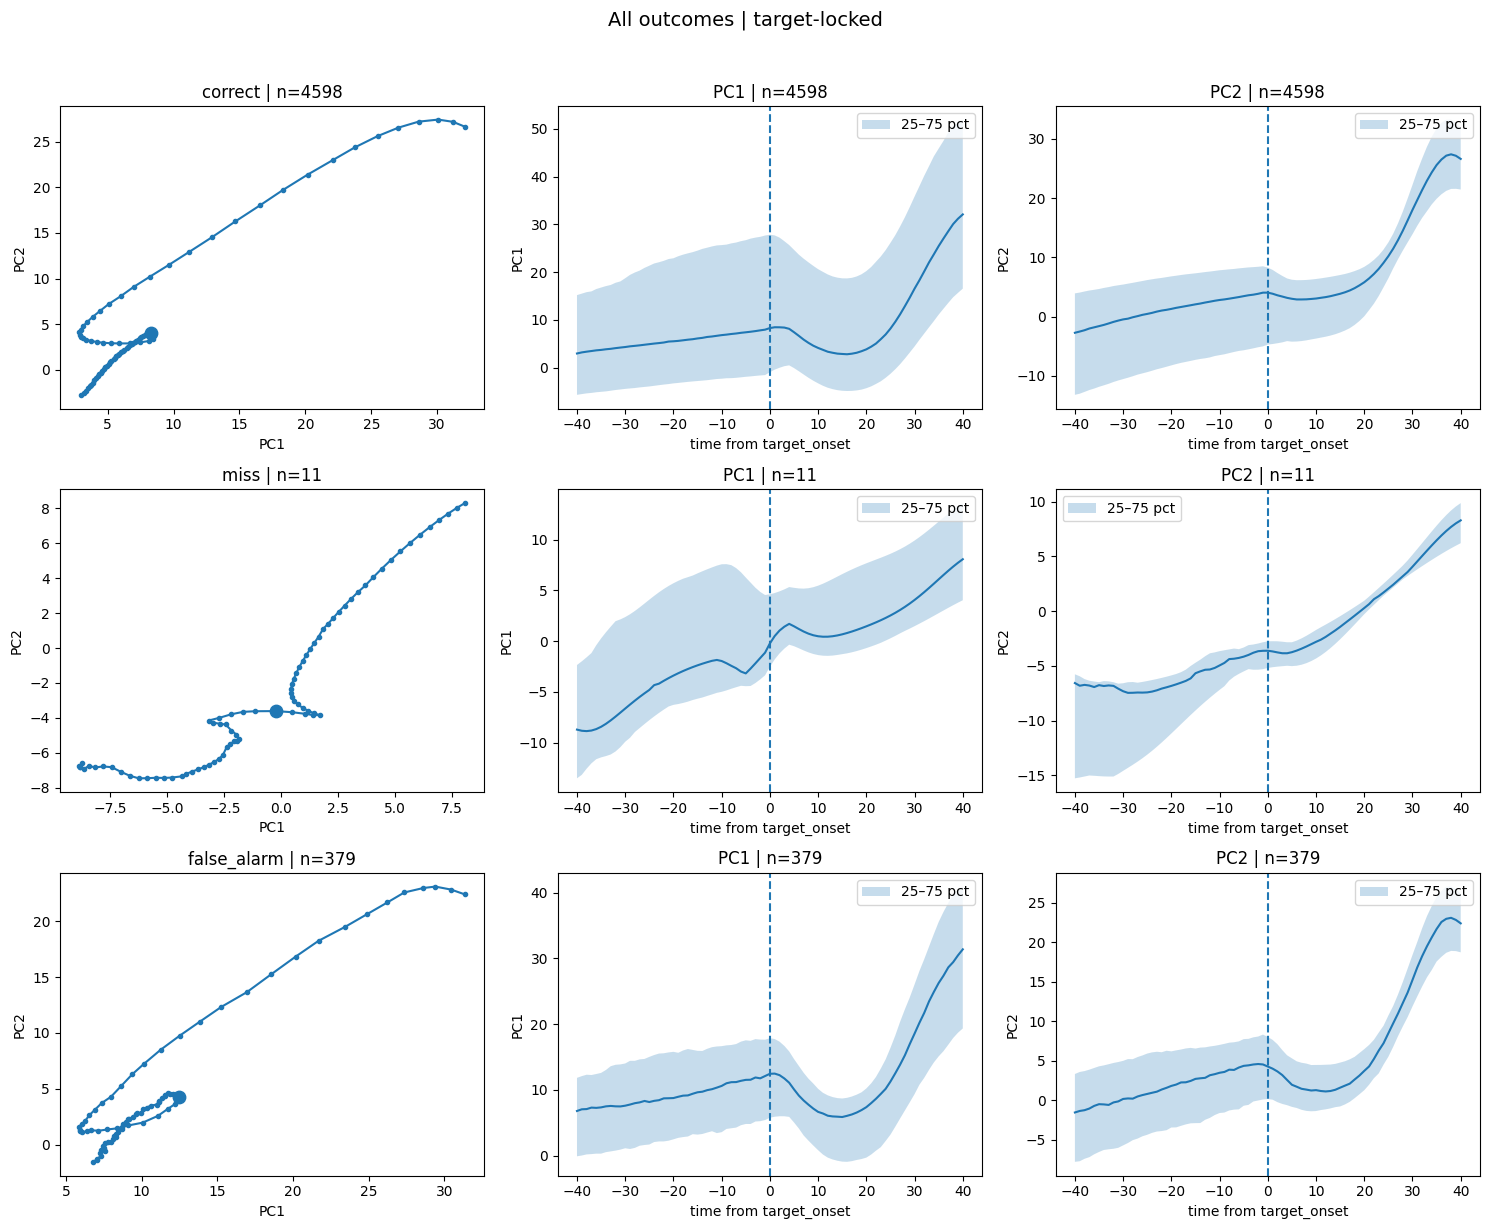

In [44]:
plot_trialtype_panel(
    trials, trial_proj,
    group_specs=[
        {'label': 'correct',     'train_outcome': 'correct'},
        {'label': 'miss',        'train_outcome': 'miss'},
        {'label': 'false_alarm', 'train_outcome': 'false_alarm'},
    ],
    align_key='target_onset', window_before=40, window_after=40,
    stat_mode='median', q_low=25, q_high=75,
    suptitle='All outcomes | target-locked',
)

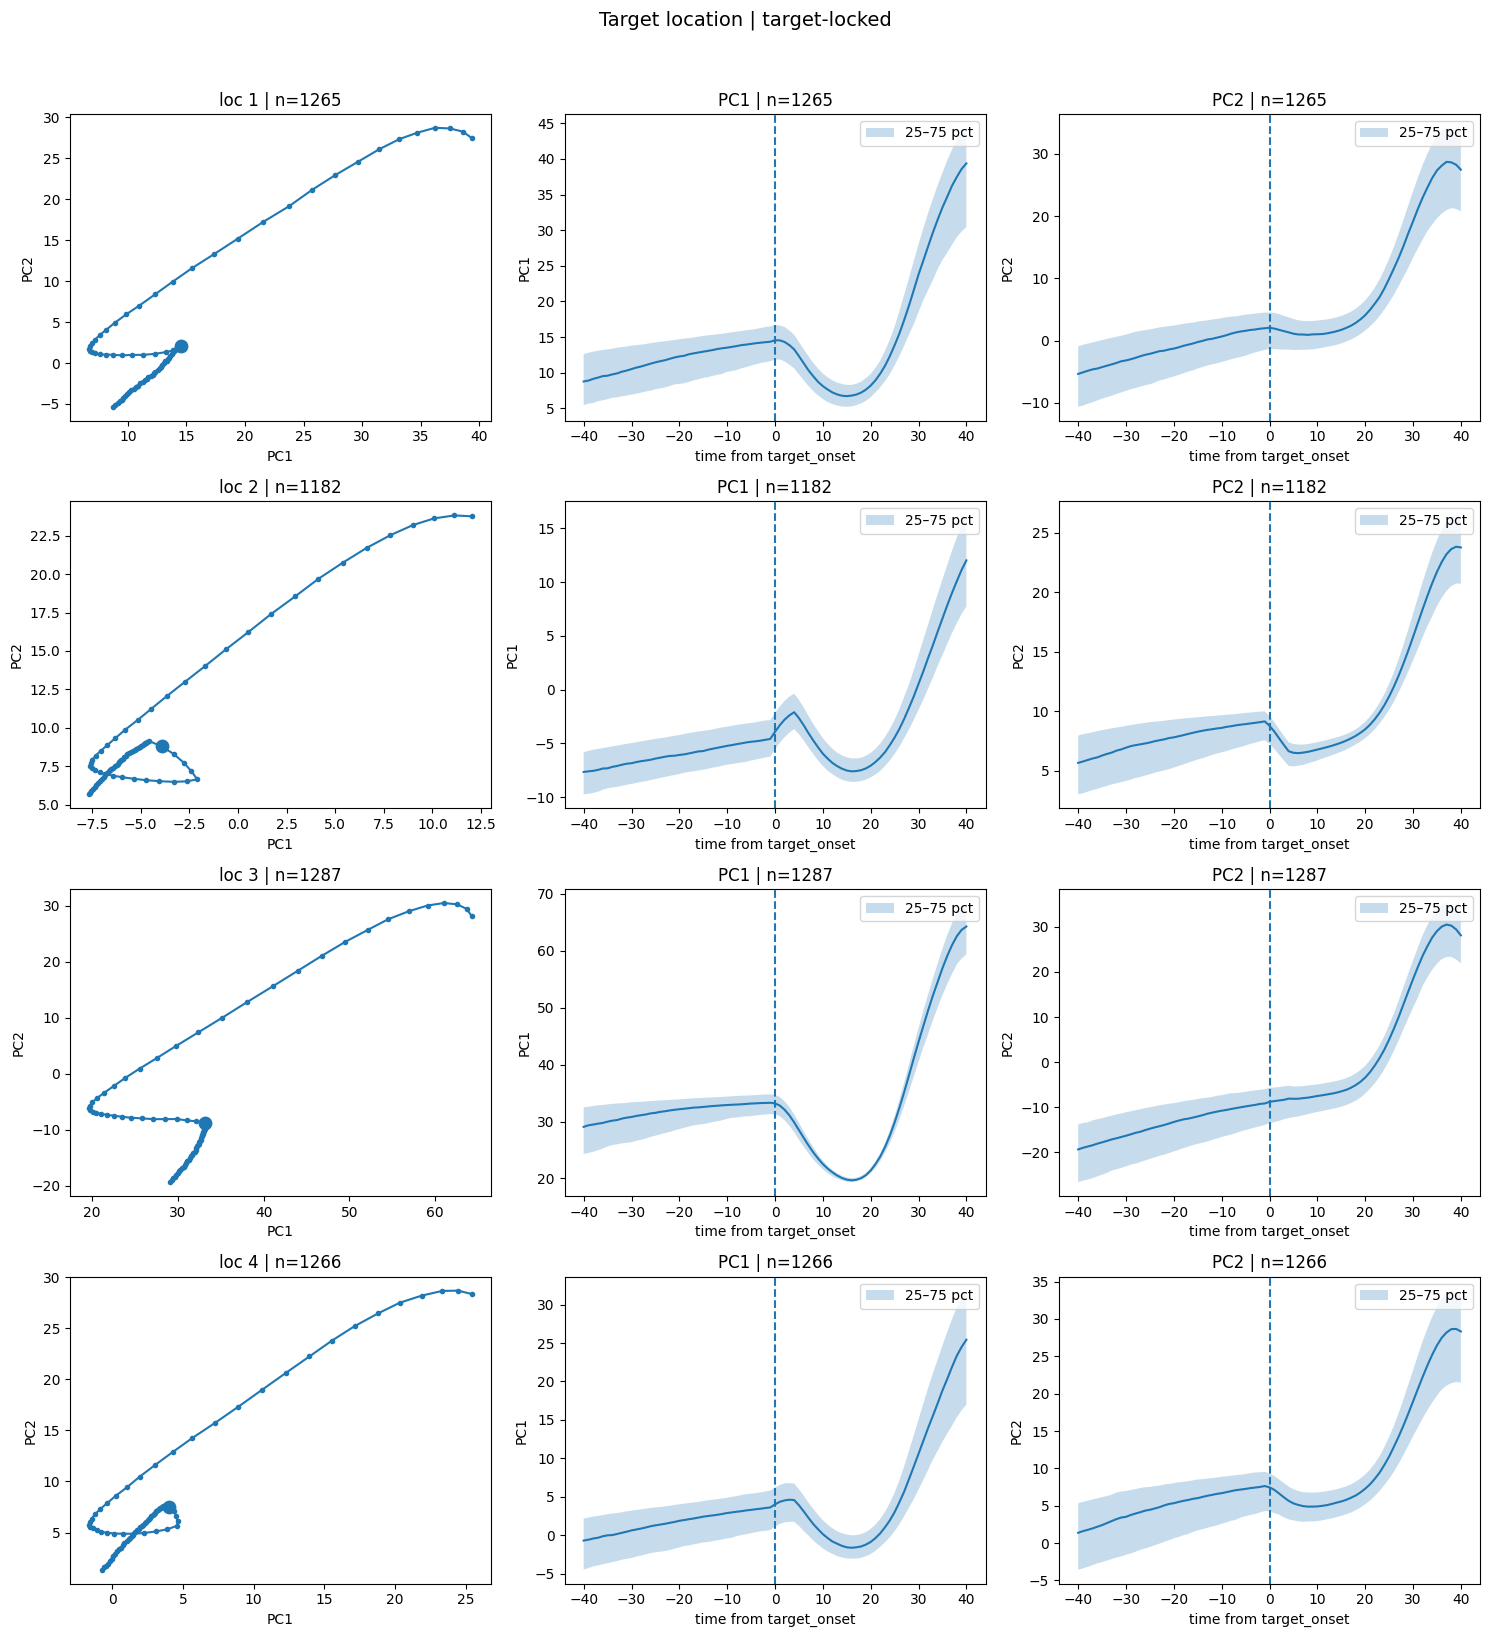

In [45]:
plot_trialtype_panel(
    trials, trial_proj,
    group_specs=[{'label': f'loc {i}', 'target_loc': i} for i in range(1, 5)],
    align_key='target_onset', window_before=40, window_after=40,
    stat_mode='median', q_low=25, q_high=75,
    suptitle='Target location | target-locked',
)

## False alarms vs aborts

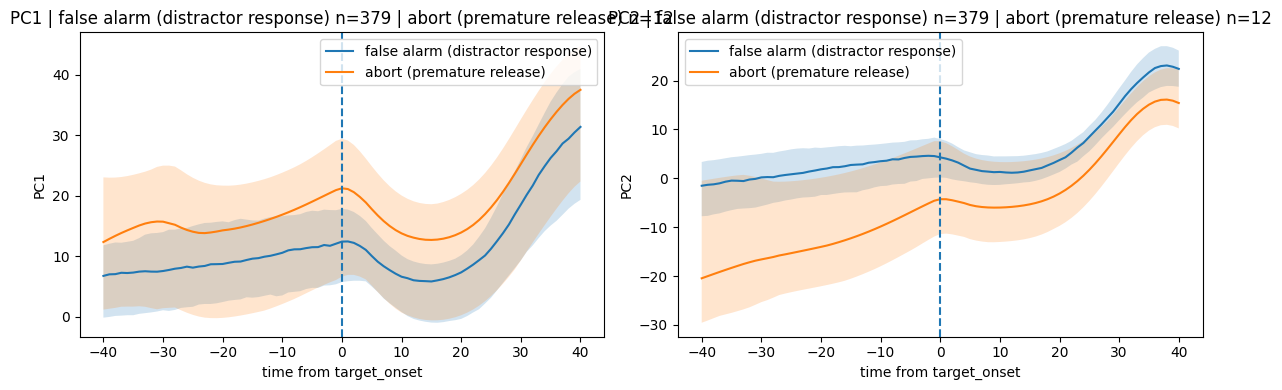

In [46]:
plot_two_group_pc_timecourses(
    trials, trial_proj,
    align_key='target_onset', window_before=40, window_after=40,
    group1_kwargs={'train_outcome': 'false_alarm'},
    group2_kwargs={'train_outcome': 'abort'},
    group1_label='false alarm (distractor response)',
    group2_label='abort (premature release)',
    stat_mode='median', q_low=25, q_high=75,
)

## dPCA: CTOA condition

In [47]:
by_ctoa, rel_time = collect_aligned_hidden_by_label(
    trials,
    label_fn=lambda tr: tr.get('ctoa_bin'),
    align_key='target_onset', window_before=40, window_after=40,
)
X_ctoa, ctoa_labels, ctoa_counts = make_condition_mean_tensor(by_ctoa, min_trials=5)
print('CTOA bins:', ctoa_labels, '  counts:', ctoa_counts)

res_ctoa = dpca_marginals(X_ctoa, n_components=3)
res_ctoa['rel_time'] = rel_time
res_ctoa['labels']   = ctoa_labels

CTOA bins: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]   counts: [75, 228, 370, 532, 660, 666, 773, 734, 639, 323]


In [ ]:
plot_dpca_components(res_ctoa, component_key='Z_time', explained_key='explained_time',
                     title_prefix='time', n_plot=3)
plot_dpca_components_with_band(res_ctoa, by_label=by_ctoa,
                                component_key='Z_cond', explained_key='explained_cond',
                                title_prefix='CTOA', n_plot=3, q_low=25, q_high=75)
plot_dpca_plane(res_ctoa, xlabel='CTOA-dPC1', ylabel='CTOA-dPC2',
                title='CTOA-demixed trajectories')

## CTOA x target position

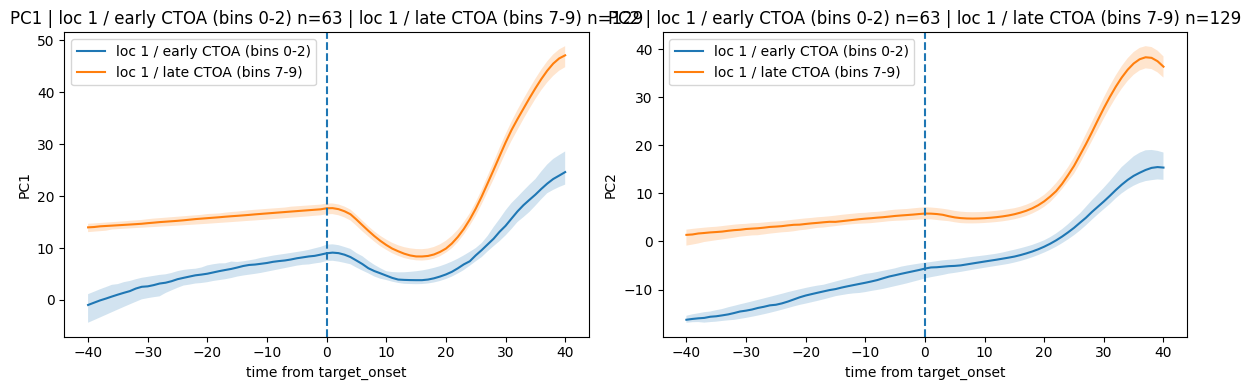

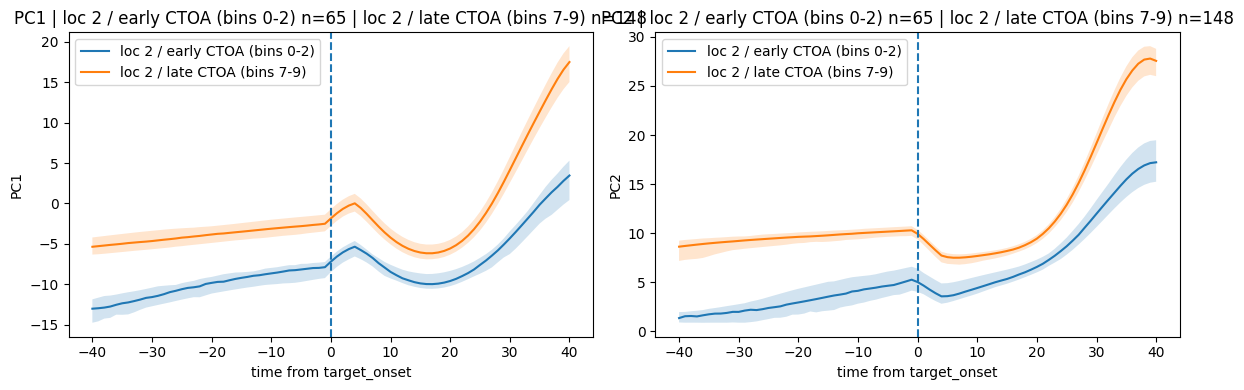

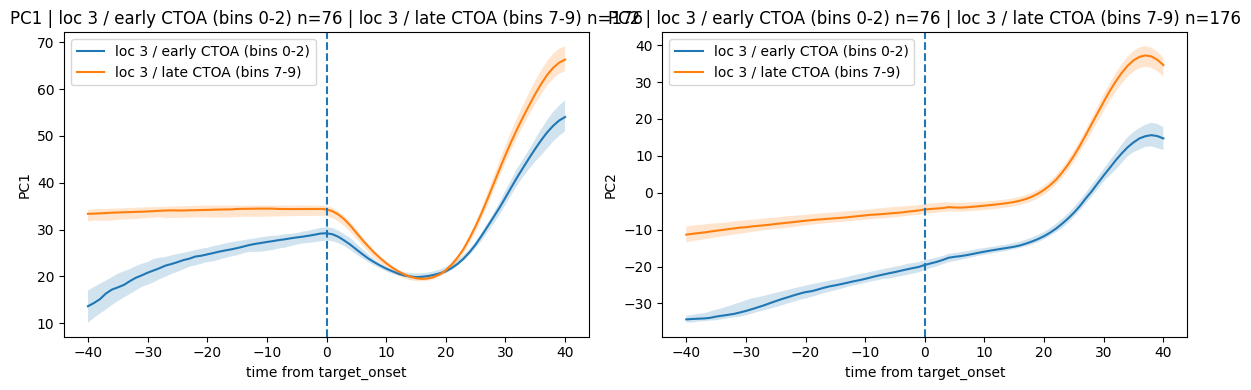

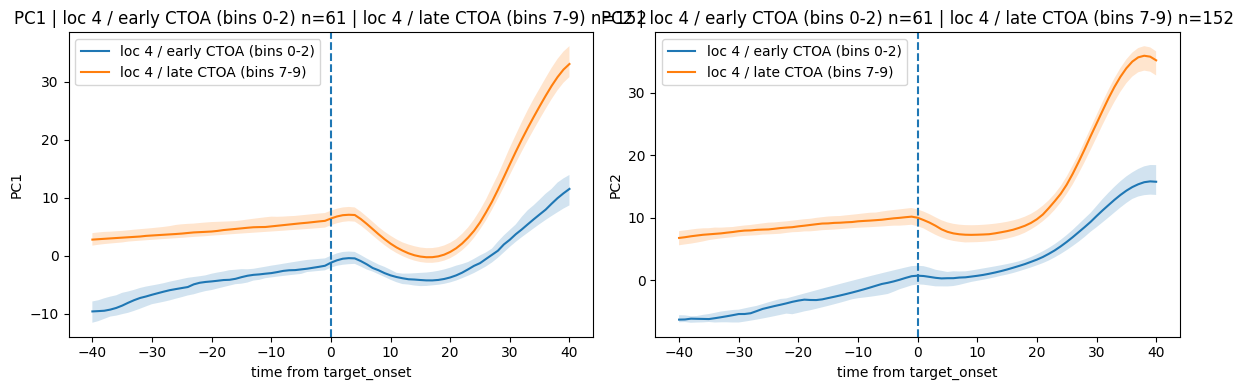

In [34]:
for loc in range(1, 5):
    plot_two_group_pc_timecourses(
        trials, trial_proj,
        align_key='target_onset', window_before=40, window_after=40,
        group1_kwargs={'train_outcome': 'correct', 'target_loc': loc, 'ctoa_bin_max': 2},
        group2_kwargs={'train_outcome': 'correct', 'target_loc': loc, 'ctoa_bin_min': 7},
        group1_label=f'loc {loc} / early CTOA (bins 0-2)',
        group2_label=f'loc {loc} / late CTOA (bins 7-9)',
        stat_mode='median', q_low=25, q_high=75,
    )

## CTOA x distractor presence

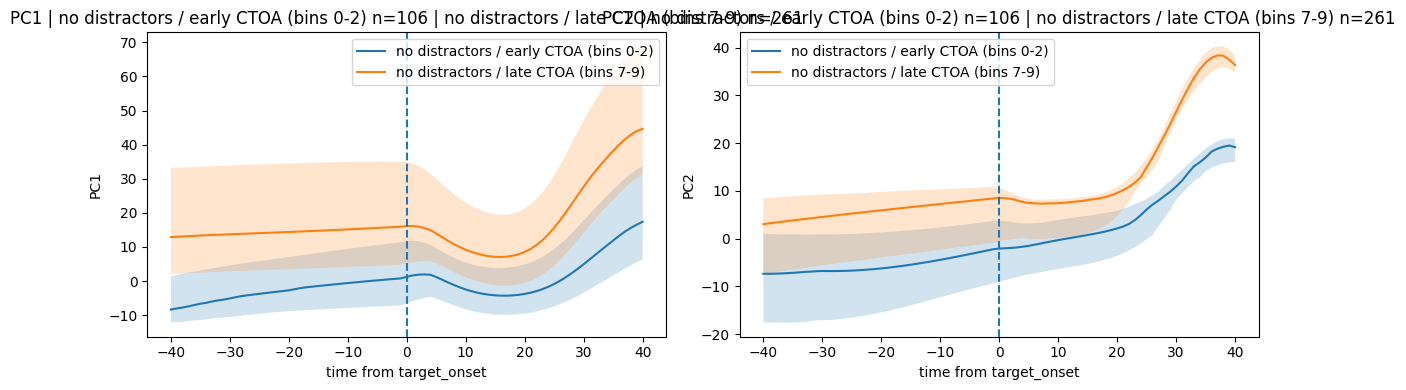

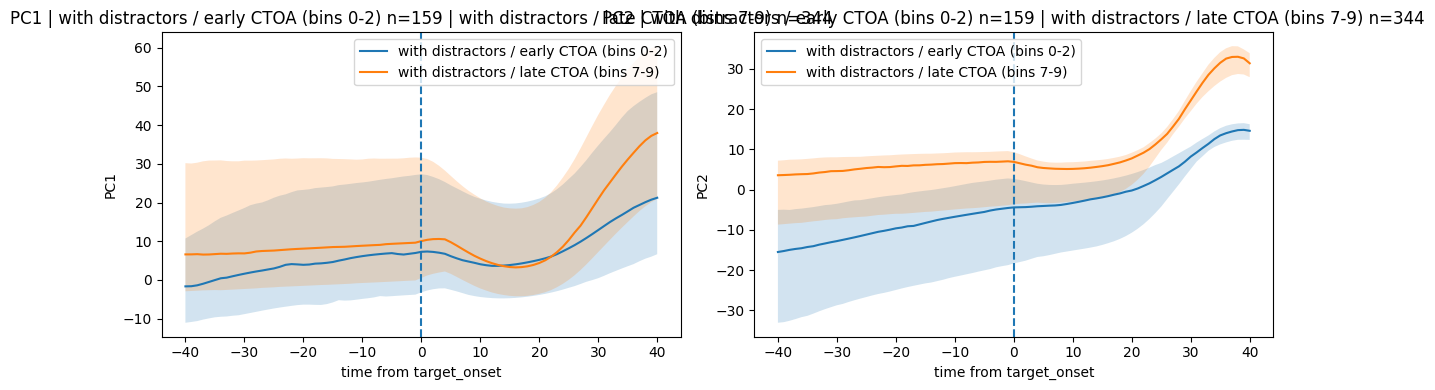

In [35]:
for has_d, label in [(False, 'no distractors'), (True, 'with distractors')]:
    plot_two_group_pc_timecourses(
        trials, trial_proj,
        align_key='target_onset', window_before=40, window_after=40,
        group1_kwargs={'train_outcome': 'correct', 'has_distractors': has_d, 'ctoa_bin_max': 2},
        group2_kwargs={'train_outcome': 'correct', 'has_distractors': has_d, 'ctoa_bin_min': 7},
        group1_label=f'{label} / early CTOA (bins 0-2)',
        group2_label=f'{label} / late CTOA (bins 7-9)',
        stat_mode='median', q_low=25, q_high=75,
    )

## Spatial separation analysis

Does the network represent target location in its hidden state?

In [36]:
# Collect more trials for spatial analysis (need enough per location)
trials_spatial = collect_trials(model, make_env_stage2, n_trials=2000, device=device)
print(Counter(tr['train_outcome'] for tr in trials_spatial))

Counter({'correct': 749, 'false_alarm': 47, 'abort': 3, 'miss': 1})


correct: 742


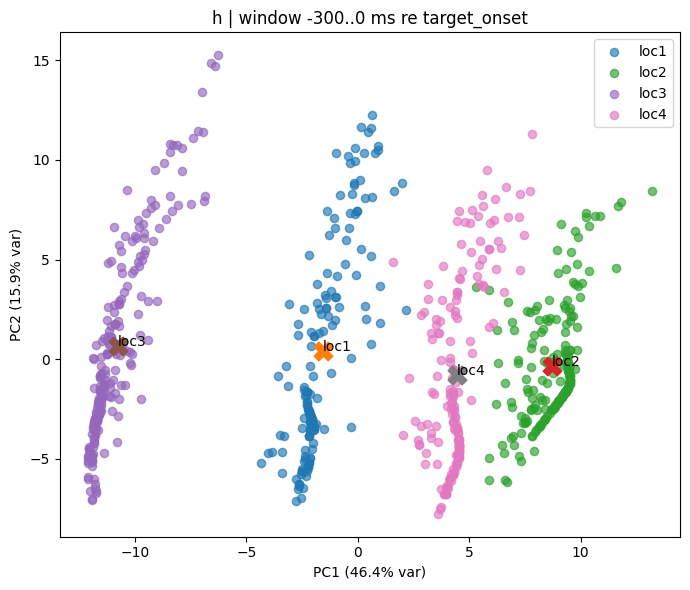

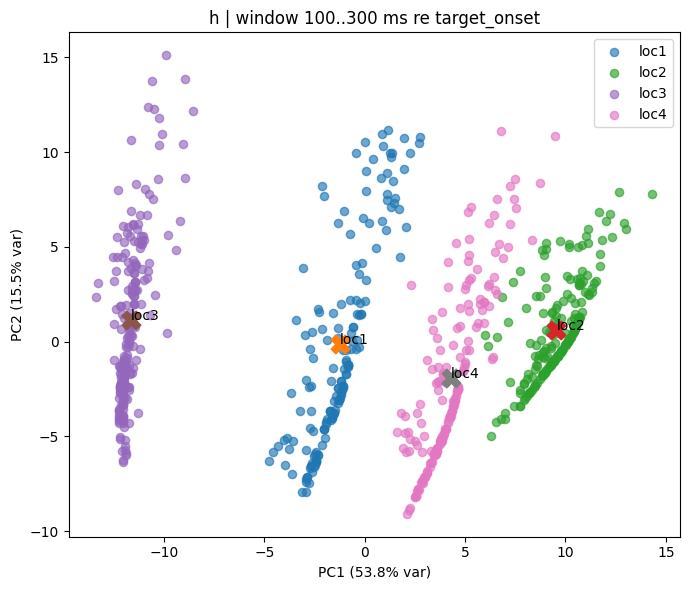

Pre-target
[[ 0.    10.311  9.195  6.152]
 [10.311  0.    19.502  4.28 ]
 [ 9.195 19.502  0.    15.296]
 [ 6.152  4.28  15.296  0.   ]]
Post-target
[[ 0.    10.83  10.489  5.809]
 [10.83   0.    21.219  5.855]
 [10.489 21.219  0.    16.232]
 [ 5.809  5.855 16.232  0.   ]]


array([[ 0.        , 10.8302145 , 10.48871708,  5.80903673],
       [10.8302145 ,  0.        , 21.2185955 ,  5.85504103],
       [10.48871708, 21.2185955 ,  0.        , 16.23184586],
       [ 5.80903673,  5.85504103, 16.23184586,  0.        ]])

In [16]:
# All correct trials: pre- vs post-target
trials_correct = filter_trials(trials_spatial, outcome='correct')
print('correct:', len(trials_correct))

res_pre  = plot_spatial_separation_pca(trials_correct, align_key='target_onset', window_ms=(-300, 0))
res_post = plot_spatial_separation_pca(trials_correct, align_key='target_onset', window_ms=(100, 300))

print_centroid_distances(res_pre,  name='Pre-target')
print_centroid_distances(res_post, name='Post-target')

hit (distractor): 374,  FA (distractor): 55
hit: n=374,  false_alarm: n=55

--- hit pre-target ---


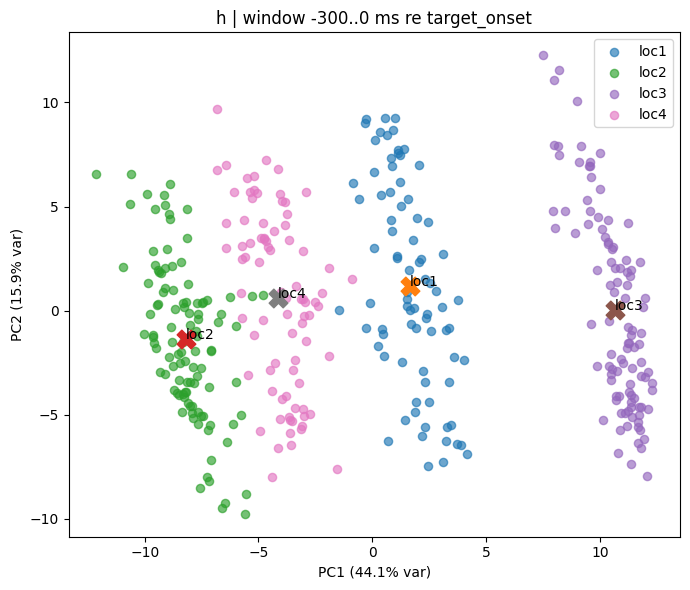

hit pre
[[ 0.    10.172  9.08   5.812]
 [10.172  0.    18.898  4.513]
 [ 9.08  18.898  0.    14.795]
 [ 5.812  4.513 14.795  0.   ]]

--- hit post-target ---


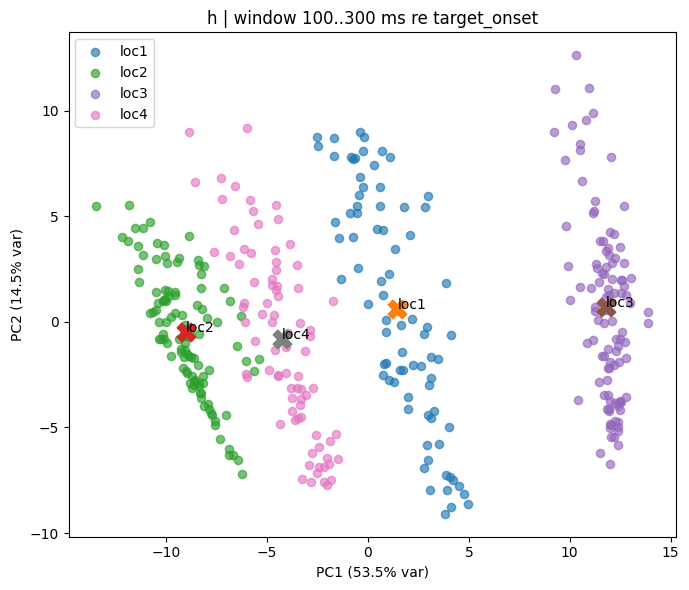

hit post
[[ 0.    10.546 10.328  5.91 ]
 [10.546  0.    20.851  4.764]
 [10.328 20.851  0.    16.137]
 [ 5.91   4.764 16.137  0.   ]]

--- false_alarm pre-target ---


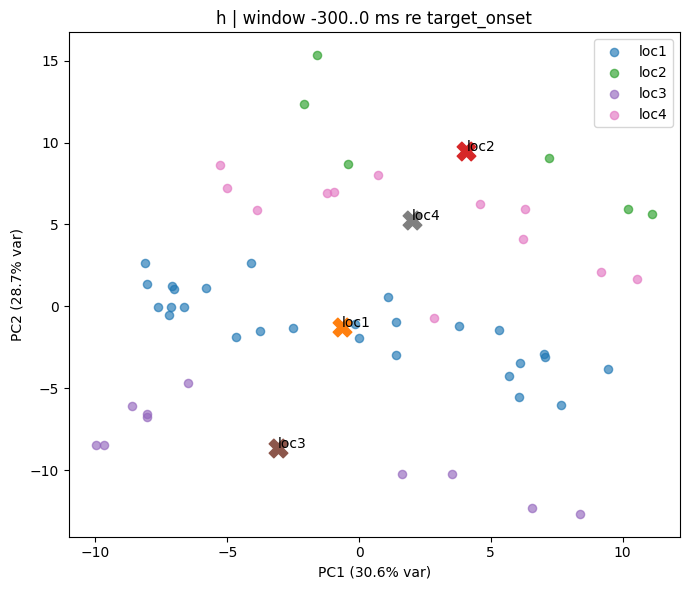

false_alarm pre
[[ 0.    11.726  7.795  7.015]
 [11.726  0.    19.497  4.716]
 [ 7.795 19.497  0.    14.8  ]
 [ 7.015  4.716 14.8    0.   ]]

--- false_alarm post-target ---


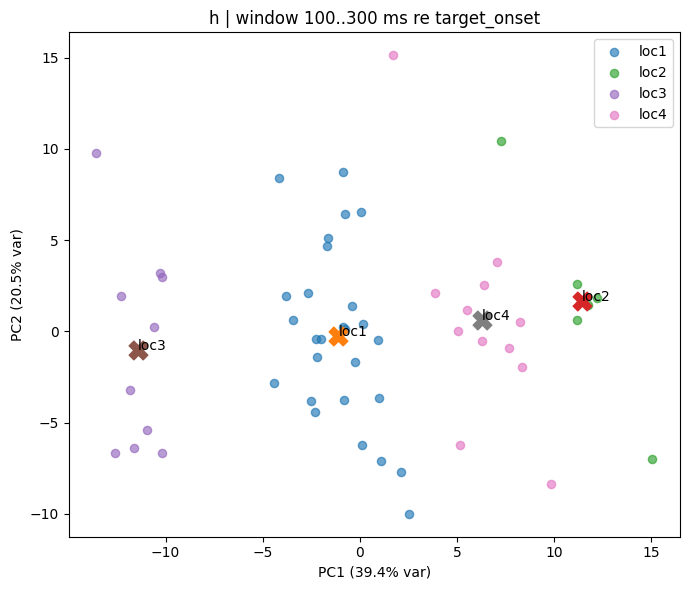

false_alarm post
[[ 0.    12.687 10.331  7.414]
 [12.687  0.    23.     5.284]
 [10.331 23.     0.    17.74 ]
 [ 7.414  5.284 17.74   0.   ]]


{'A': {'pre': {'X': array([[ 0.01944488,  2.218753  ,  6.253429  , ...,  0.42746037,
            0.4985961 , 10.267848  ],
          [ 0.06528781,  0.74145526,  2.374085  , ...,  0.5166667 ,
            1.5352213 ,  5.0518713 ],
          [ 0.32153958,  2.9109716 ,  5.0094786 , ...,  0.5144862 ,
            0.61612207,  5.0871305 ],
          ...,
          [ 1.0105215 ,  3.658193  ,  5.8615665 , ...,  0.21119456,
            0.24953339,  9.082966  ],
          [ 0.08134436,  4.495293  ,  6.143297  , ...,  0.51072437,
            0.96458143,  8.228459  ],
          [ 0.11610389,  2.0363698 ,  2.3812032 , ...,  0.7517033 ,
            0.747793  ,  4.6010127 ]], dtype=float32),
   'X_plot': array([[-0.80683464, -0.00970861,  1.1744057 , ..., -0.61196005,
           -0.55693805,  1.7192894 ],
          [-0.57630044, -1.3128479 , -0.47158882, ..., -0.12642474,
            2.2494822 , -0.65947473],
          [ 0.7123343 ,  0.6009043 ,  0.64660114, ..., -0.13829294,
           -0.238764  , -

In [17]:
# Correct+distractor vs false-alarm: does pre-target geometry predict outcome?
trials_hit = filter_trials(trials_spatial, outcome='correct',     require_distractors=True)
trials_fa  = filter_trials(trials_spatial, outcome='false_alarm', require_distractors=True)
print(f'hit (distractor): {len(trials_hit)},  FA (distractor): {len(trials_fa)}')

compare_spatial_separation(trials_hit, trials_fa, label_A='hit', label_B='false_alarm')

In [ ]:
trials_miss = filter_trials(trials_spatial, outcome='miss')
print('miss:', len(trials_miss))

if len(trials_miss) > 0:
    res_miss_pre  = plot_spatial_separation_pca(trials_miss, align_key='target_onset', window_ms=(-300, 0))
    res_miss_post = plot_spatial_separation_pca(trials_miss, align_key='target_onset', window_ms=(100, 300))
    print_centroid_distances(res_miss_pre,  name='Miss pre-target')
    print_centroid_distances(res_miss_post, name='Miss post-target')
else:
    print('Not enough miss trials to plot spatial separation.')